# AED guiado pelo DAMICORE: quais campos do Disque 100 perguntar?

**Problema.** O formulário de denúncia tem 15 campos. Queremos saber quais
perguntar para identificar emergências fazendo **o menor número de perguntas**.

**Hipótese.** Um Algoritmo de Estimação de Distribuição (AED) cujo modelo
probabilístico é construído pelo DAMICORE encontra os formulários com o melhor
compromisso entre número de campos e informação sobre emergência.

O método segue o slide "DAMICORE gerando modelos para AEDs"
(`docs/AED Proposito Geral.pdf`), trocando a extrusora pelo formulário:

| Extrusora (slide) | Formulário do Disque 100 |
| --- | --- |
| Variáveis: P, N, D1, D3, L1… | 15 campos: perguntar (1) ou não (0) |
| Minimizar a energia E | Minimizar o número de campos |
| Maximizar a massa processada Q | Maximizar a informação sobre emergência |
| Valores das soluções promissoras, um arquivo por variável | Igual |
| DAMICORE identifica os grupos de variáveis | Igual |
| Tabela de probabilidades de cada grupo | Igual |
| Amostragem gera novas extrusoras | Amostragem gera novos formulários |
| Mede E e Q, seleciona as melhores e repete | Igual |

**Alvo:** o status de emergência é a marcação histórica do banco, não uma
confirmação independente de urgência.


## 1. Dados

Cada linha é uma denúncia. Quatro status contam como emergência e `NÃO` como não
emergência; status ausentes ou conflitantes saem. O perfil `full` usa 2024-01 a
2026-06: três trimestres de validação (2025-Q3, 2025-Q4, 2026-Q1) para medir os
formulários e 2026-Q2 reservado para a conferência final.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import toytree
from IPython.display import display

os.environ.setdefault("EMERGENCY_DATA_PROFILE", "full")

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Open this notebook from the repository environment.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from hypotheses.emergency_feature_selection.scripts.config import (
    DEFAULT_CONFIG,
    FEATURES,
    active_profile,
)
from hypotheses.emergency_feature_selection.scripts.data import prepare_data
from hypotheses.emergency_feature_selection.scripts.experiment import (
    execute_experiment,
)
from hypotheses.emergency_feature_selection.scripts.fitness import (
    MaskEvaluator,
    code_folds,
    selected_features,
)

profile = active_profile()
prepared = prepare_data(profile=profile)
audit_summary = {
    key: value
    for key, value in prepared.audit.items()
    if key not in {"validation_folds", "feature_conflicts"}
}
print(f"Profile: {profile.name}; reserved period: {profile.test_name}")
display(pd.Series(audit_summary, name="value").to_frame())


/Users/erickpatrickbarcelos/codes/data-mining/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Profile: full; reserved period: 2026-Q2


,value
reports_in_scope,1560700
date_conflicts,0
status_conflicts,0
unknown_status,10
unsupported_status,0
usable_reports,1560690
latest_registered_at,2026-06-30 23:59:03.497000
excluded_reports,10
source_table,public.disque100_reports
report_unit,one source_hash after within-report aggregation


## 2. Como medir um formulário (E e Q)

Um formulário é uma sequência de 15 bits: `1` = o campo é perguntado.

- **E (custo):** o número de campos perguntados.
- **Q (qualidade):** os campos escolhidos dividem as denúncias em grupos de
  respostas iguais. No período de treino, cada grupo recebe sua taxa de
  emergência; no período de validação seguinte, medimos quanto essas taxas
  acertam mais do que a taxa geral, em *bits por denúncia*. Combinações de
  respostas raras demais não se repetem na validação e perdem pontos, por isso
  perguntar tudo não é automaticamente o melhor.

Exemplo: a qualidade de cada campo perguntado sozinho.


In [2]:
evaluator = MaskEvaluator(code_folds(prepared.folds), DEFAULT_CONFIG)
single_fields = pd.DataFrame(
    {
        "field": feature,
        "gain_bits": evaluator.quality(
            tuple(int(position == index) for position in range(len(FEATURES)))
        ),
    }
    for index, feature in enumerate(FEATURES)
).sort_values("gain_bits", ascending=False)
display(single_fields.round(5))


,field,gain_bits
7,victim_suspect_relationship,0.00210
10,victim_disability,0.00199
9,victim_age_group,0.00167
3,frequency,0.00119
5,vulnerable_group,0.00118
2,violation_setting,0.00079
8,victim_gender,0.00053
13,suspect_gender,0.00019
4,violation_start_period,0.00014
12,suspect_age_group,0.00005


## 3. Rodar o AED guiado pelo DAMICORE

Cada execução começa com 400 formulários variados e faz 10 gerações de 80
formulários novos (1.200 avaliações). Em cada geração:

1. **Seleção:** os 30% melhores formulários avaliados até agora, pela frente de
   Pareto (mais Q com menos E).
2. **Variáveis como amostras:** cada campo vira um arquivo com a sequência de
   0/1 dele nesses formulários, todos na mesma ordem.
3. **DAMICORE:** matriz NCD → árvore Neighbor-Joining → grupos FastGreedy.
4. **Tabela de probabilidades** de cada grupo de campos.
5. **Amostragem** de novos formulários a partir das tabelas.
6. **Avaliação** de E e Q dos novos formulários, e volta ao passo 1.

O AED roda com 10 sementes para mostrar que o resultado não depende do sorteio.


In [3]:
results = execute_experiment(prepared, DEFAULT_CONFIG)
print(f"Run artifacts: {results.output_dir}")


Run artifacts: /Users/erickpatrickbarcelos/codes/data-mining/hypotheses/emergency_feature_selection/artifacts/full-20260928T163425Z


## 4. Uma geração por dentro

Primeira geração da primeira execução. Abaixo: o começo de cada arquivo (um
caractere por formulário promissor), a árvore que o DAMICORE montou com esses
arquivos, os grupos que ele encontrou e as tabelas de probabilidade de cada grupo.


service_channel              000000000000000000000000000000010100000000001000000000100010…  (120 formulários)
reporter_type                000001000010100000100000001010010001000000010000000110000001…  (120 formulários)
violation_setting            000000001010000101001100100000000100100100100000100000000100…  (120 formulários)
frequency                    101101111110010100101100001001010111000001001010000000011000…  (120 formulários)
violation_start_period       000000000000000100000000000001100001000001110000100010100001…  (120 formulários)
vulnerable_group             000000101001101100000001001011010010100000000000100001100101…  (120 formulários)
motivation                   000000010000000000000000000000000000000000000001010000000000…  (120 formulários)
victim_suspect_relationship  100001010011000010010100101110000001000000001000110010100000…  (120 formulários)
victim_gender                100101001010010000001110100100010000101100000000000000000000…  (120 formulários)
victim_age

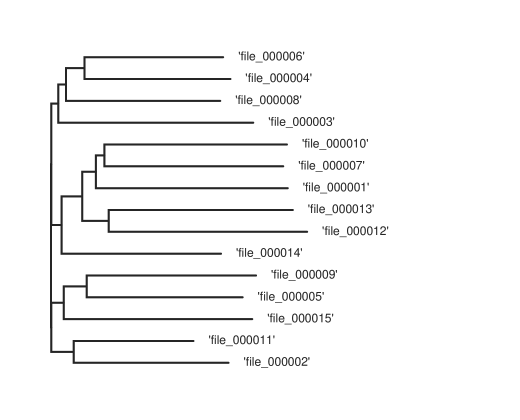

,block_id,feature_count,features
0,1,3,"service_channel, motivation, victim_age_group"
1,2,2,"reporter_type, victim_disability"
2,3,4,"violation_setting, frequency, vulnerable_group..."
3,4,3,"violation_start_period, victim_gender, suspect..."
4,5,3,"victim_race_color, suspect_age_group, suspect_..."


,block_id,features,pattern,promising_count,laplace_alpha,smoothed_probability
0,1,"service_channel, motivation, victim_age_group",0,69,1.0,0.546875
1,1,"service_channel, motivation, victim_age_group",100,17,1.0,0.140625
2,1,"service_channel, motivation, victim_age_group",10,19,1.0,0.156250
3,1,"service_channel, motivation, victim_age_group",110,1,1.0,0.015625
4,1,"service_channel, motivation, victim_age_group",1,9,1.0,0.078125
5,1,"service_channel, motivation, victim_age_group",101,1,1.0,0.015625
6,1,"service_channel, motivation, victim_age_group",11,4,1.0,0.039062
7,1,"service_channel, motivation, victim_age_group",111,0,1.0,0.007812
8,2,"reporter_type, victim_disability",0,65,1.0,0.532258
9,2,"reporter_type, victim_disability",10,24,1.0,0.201613


In [4]:
seed = DEFAULT_CONFIG.seeds[0]
generation_dir = results.output_dir / "searches" / f"seed-{seed}" / "generation-01"
names = {f"feature-{index:02d}.txt": name for index, name in enumerate(FEATURES)}

for file_name, feature in names.items():
    series = (generation_dir / "feature_series" / file_name).read_text()
    print(f"{feature:<28} {series[:60]}…  ({len(series)} formulários)")

tree = toytree.tree((generation_dir / "tree.nwk").read_text(encoding="utf-8"))
labels = [names.get(str(tip).strip("'\""), str(tip)) for tip in tree.get_tip_labels()]
canvas, _, _ = tree.draw(tip_labels=labels, width=520, height=420)
display(canvas)

blocks = results.damicore_blocks
display(
    blocks.loc[
        (blocks["seed"] == seed) & (blocks["generation"] == 1),
        ["block_id", "feature_count", "features"],
    ]
)
display(pd.read_csv(generation_dir / "probability_tables.csv"))


## 5. Evolução ao longo das gerações

Se o modelo do DAMICORE aprende com os formulários promissores, os formulários
sorteados a cada geração devem ficar melhores. O segundo gráfico mostra com que
frequência o DAMICORE colocou dois campos no mesmo grupo, somando todas as
gerações e sementes.


,bytes_per_series,block_count,largest_block,ncd_median
generation,,,,
1,120.0,5.1,3.9,0.590
2,144.0,4.6,4.7,0.608
3,168.0,4.6,4.4,0.623
4,192.0,4.6,4.9,0.652
5,216.0,4.3,4.6,0.672
6,240.0,4.8,4.2,0.686
7,264.0,4.6,4.3,0.709
8,288.0,5.2,3.9,0.723
9,312.0,4.7,4.6,0.733


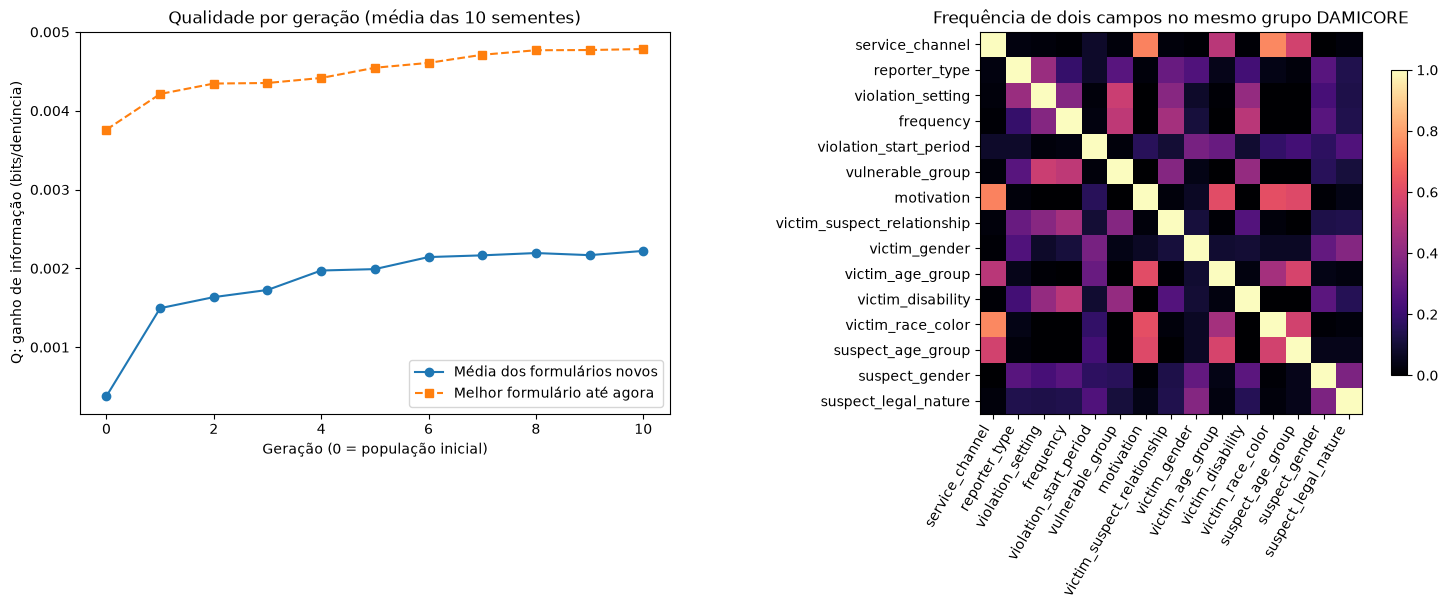

In [5]:
progress = (
    results.generation_progress.groupby("generation")[
        ["new_masks_mean_gain", "best_gain_so_far"]
    ]
    .mean()
    .reset_index()
)
display(results.damicore_diagnostics.groupby("generation")[
    ["bytes_per_series", "block_count", "largest_block", "ncd_median"]
].mean().round(3))

figure, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(progress["generation"], progress["new_masks_mean_gain"], "o-",
             label="Média dos formulários novos")
axes[0].plot(progress["generation"], progress["best_gain_so_far"], "s--",
             label="Melhor formulário até agora")
axes[0].set(
    xlabel="Geração (0 = população inicial)",
    ylabel="Q: ganho de informação (bits/denúncia)",
    title="Qualidade por geração (média das 10 sementes)",
)
axes[0].legend()

image = axes[1].imshow(results.block_cooccurrence.to_numpy(), cmap="magma", vmin=0, vmax=1)
axes[1].set_xticks(range(len(FEATURES)), FEATURES, rotation=60, ha="right")
axes[1].set_yticks(range(len(FEATURES)), FEATURES)
axes[1].set_title("Frequência de dois campos no mesmo grupo DAMICORE")
figure.colorbar(image, ax=axes[1], shrink=0.8)
figure.tight_layout()
plt.show()


## 6. Formulário recomendado

A frente de Pareto reúne, para cada número de campos, o melhor formulário que o
AED encontrou. A recomendação é o formulário com **menos campos** que alcança 95%
da melhor qualidade da frente. Por fim, medimos a mesma qualidade no período
reservado, que o AED nunca viu, ao lado do formulário com os 15 campos.


,feature_count,mean_gain_bits,fields
0,1,0.002100,victim_suspect_relationship
1,2,0.003471,"frequency, victim_suspect_relationship"
2,3,0.004102,"frequency, victim_suspect_relationship, victim..."
3,4,0.004239,"violation_setting, frequency, vulnerable_group..."
4,5,0.004632,"reporter_type, violation_setting, frequency, v..."
5,6,0.004873,"reporter_type, violation_setting, frequency, v..."


Recommended fields: ['reporter_type', 'violation_setting', 'frequency', 'vulnerable_group', 'victim_disability']


,form,feature_count,fields,test_period,gain_bits
0,recommended,5,"reporter_type, violation_setting, frequency, v...",2026-Q2,0.00589
1,all_fields,15,"service_channel, reporter_type, violation_sett...",2026-Q2,0.00057


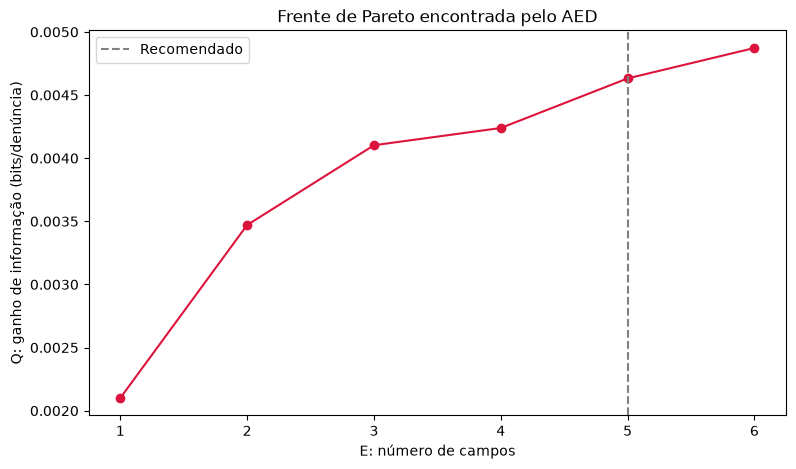

In [6]:
display(results.aed_front[["feature_count", "mean_gain_bits", "fields"]])
print("Recommended fields:", selected_features(results.recommended_mask))
display(results.held_out.round(5))

front = results.aed_front
figure, axis = plt.subplots(figsize=(9, 5))
axis.plot(front["feature_count"], front["mean_gain_bits"], "o-", color="crimson")
axis.axvline(sum(results.recommended_mask), color="gray", linestyle="--",
             label="Recomendado")
axis.set(
    xlabel="E: número de campos",
    ylabel="Q: ganho de informação (bits/denúncia)",
    title="Frente de Pareto encontrada pelo AED",
)
axis.legend()
plt.show()


## 7. Conferência com o gabarito

Com 15 campos existem 32.767 formulários possíveis, poucos o bastante para medir
todos e saber a resposta certa. Isso não faz parte do AED: serve só para conferir
se ele chegou ao melhor formulário avaliando uma pequena fração deles.


In [7]:
audit = results.audit
print(f"Avaliações por execução: {audit['evaluations_per_run']} "
      f"({audit['share_of_all_forms_per_run']:.1%} dos formulários possíveis)")
print("Gabarito:", audit["ground_truth_recommended_fields"])
print("AED:     ", audit["recommended_fields"])
print("Mesmo formulário:", audit["recommended_matches_ground_truth"])
display(results.seed_recommendations)


Avaliações por execução: 1200 (3.7% dos formulários possíveis)
Gabarito: ['reporter_type', 'violation_setting', 'frequency', 'vulnerable_group', 'victim_disability']
AED:      ['reporter_type', 'violation_setting', 'frequency', 'vulnerable_group', 'victim_disability']
Mesmo formulário: True


,seed,evaluations,recommended_fields,matches_ground_truth,true_front_points_found,true_front_size
0,101,1200,"reporter_type, frequency, vulnerable_group, vi...",False,4,6
1,202,1200,"reporter_type, violation_setting, frequency, v...",False,4,6
2,303,1200,"reporter_type, violation_setting, frequency, v...",True,5,6
3,404,1200,"reporter_type, violation_setting, frequency, v...",True,5,6
4,505,1200,"reporter_type, violation_setting, frequency, v...",True,6,6
5,606,1200,"reporter_type, violation_setting, frequency, v...",True,5,6
6,707,1200,"reporter_type, violation_setting, frequency, v...",True,6,6
7,808,1200,"reporter_type, violation_setting, frequency, v...",True,5,6
8,909,1200,"reporter_type, violation_setting, frequency, v...",False,5,6
9,1010,1200,"reporter_type, violation_setting, frequency, v...",True,6,6


## 8. Limites

- O alvo reproduz a marcação histórica de emergência, não urgência verificada.
- O sinal é fraco: mesmo o melhor formulário explica pouco da marcação.
- O NCD compara sequências de 0/1: reconhece campos que costumam entrar juntos
  nos formulários bons, mas não campos que se substituem (um entra quando o outro
  sai).
- O gabarito só é possível porque há 15 campos; com muitos mais, só o AED
  resolveria.
